## Generate plots to show the distributions of the failed versus passing cells

We use the `PCCMA optimization` dataset.

In [1]:
import re
import warnings
from pathlib import Path

import pandas as pd
from cytodataframe import CytoDataFrame
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_bar,
    geom_bin2d,
    geom_histogram,
    geom_hline,
    geom_point,
    geom_vline,
    ggplot,
    ggtitle,
    guides,
    labs,
    scale_color_manual,
    scale_fill_gradient,
    scale_fill_manual,
    scale_x_continuous,
    theme,
    theme_bw,
    theme_light,
)
from plotnine.options import set_option
from pycytominer import annotate

from cosmicqc import find_outliers, identify_outliers

In [2]:
# Set the figure size for all plots
height = 6
width = 8
set_option("figure_size", (width, height))

# Set output directory for figures
output_dir = Path("./figures")
output_dir.mkdir(parents=True, exist_ok=True)

# set plate to analyze
plate_id = "BR00145816"

In [3]:
# Load the data to generate the plots
example_df = pd.read_parquet(
    Path(
        f"/media/18tbdrive/1.Github_Repositories/pediatric_cancer_atlas_profiling/3.preprocessing_features/data/converted_profiles/Round_2_data/{plate_id}_converted.parquet"
    )
)

# Print the shape of the dataframe
print(example_df.shape)

(78602, 3035)


In [4]:
# Load the data to generate the plots
example_df = pd.read_parquet(
    Path(
        f"/media/18tbdrive/1.Github_Repositories/pediatric_cancer_atlas_profiling/3.preprocessing_features/data/converted_profiles/Round_2_data/{plate_id}_converted.parquet"
    )
)

# metadata columns to include in output data frame
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
    "Image_FileName_OrigDNA",
    "Image_FileName_OrigAGP",
    "Image_PathName_OrigDNA",
    "Image_PathName_OrigAGP",
    "Nuclei_AreaShape_BoundingBoxMaximum_X",
    "Nuclei_AreaShape_BoundingBoxMaximum_Y",
    "Nuclei_AreaShape_BoundingBoxMinimum_X",
    "Nuclei_AreaShape_BoundingBoxMinimum_Y",
    "Image_Metadata_Row",
    "Image_Metadata_Col",
    "Metadata_Nuclei_Number_Object_Number",
]

# Define the QC features
qc_features = [
    "Nuclei_Intensity_IntegratedIntensity_CorrDNA",
    "Nuclei_AreaShape_Solidity",
    "Nuclei_Intensity_MassDisplacement_CorrDNA",
    "Cells_Intensity_IntegratedIntensity_CorrDNA",
]

# Filter plate_df to only include metadata columns and QC features
filtered_plate_df = example_df[metadata_columns + qc_features]

print(example_df.shape)
example_df.head()

(78602, 3035)


,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Image_Metadata_Col,Image_Metadata_Plate,Image_Metadata_Row,Image_Metadata_Site,...,Nuclei_Texture_Variance_CorrER_3_02_256,Nuclei_Texture_Variance_CorrER_3_03_256,Nuclei_Texture_Variance_CorrMito_3_00_256,Nuclei_Texture_Variance_CorrMito_3_01_256,Nuclei_Texture_Variance_CorrMito_3_02_256,Nuclei_Texture_Variance_CorrMito_3_03_256,Nuclei_Texture_Variance_CorrRNA_3_00_256,Nuclei_Texture_Variance_CorrRNA_3_01_256,Nuclei_Texture_Variance_CorrRNA_3_02_256,Nuclei_Texture_Variance_CorrRNA_3_03_256
0,336.377009,104.297899,352.210413,116.052065,10,1,1,BR00145816,2,1,...,189.867760,175.258056,9.359696,9.455868,9.342000,8.864129,71.653567,78.652402,72.325106,67.668053
1,498.383356,81.555252,493.371429,74.367347,14,6,1,BR00145816,2,6,...,37.010230,42.539795,2.056842,2.040540,2.121985,2.797201,6.598058,6.854488,6.605123,6.568223
2,296.924490,42.889796,290.397623,54.289762,18,7,1,BR00145816,2,7,...,229.314572,218.190815,10.576748,10.938701,9.687250,8.795027,63.617244,65.864101,63.804281,64.184465
3,787.229535,286.391653,783.873688,289.240187,10,8,1,BR00145816,2,8,...,1496.307081,1538.527119,136.357027,127.891993,140.240277,141.944781,261.830682,243.596874,249.175994,255.187774
4,891.834437,104.026490,892.879444,102.732612,16,22,1,BR00145816,4,4,...,159.236979,153.487704,3.661602,3.331812,3.183244,3.233278,10.138008,9.798398,9.062918,8.676421


In [5]:
# Find large nuclei outliers for the current plate
identify_nuclei_clustered_outliers = identify_outliers(
    df=filtered_plate_df,
    feature_thresholds={
        # Set very low as to detect all instances of clustering nuclei
        "Nuclei_Intensity_MassDisplacement_CorrDNA": 0.05,
        # Set higher than displacement to avoid false positives
        "Nuclei_Intensity_IntegratedIntensity_CorrDNA": 1.5,
    },
    include_threshold_scores=True,
)

pd.DataFrame(identify_nuclei_clustered_outliers).head()

,Metadata_cqc_custom_Nuclei_Intensity_MassDisplacement_CorrDNA_zscore,Metadata_cqc_custom_Nuclei_Intensity_IntegratedIntensity_CorrDNA_zscore,Metadata_cqc_custom_is_outlier
0,0.878023,-0.267815,False
1,-0.498469,-0.569057,False
2,-0.892600,-0.616416,False
3,1.273175,1.272925,False
4,-0.640144,-0.684732,False


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/under_segmented_nuclei_plot.png
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/under_segmented_nuclei_plot_no_legend.png


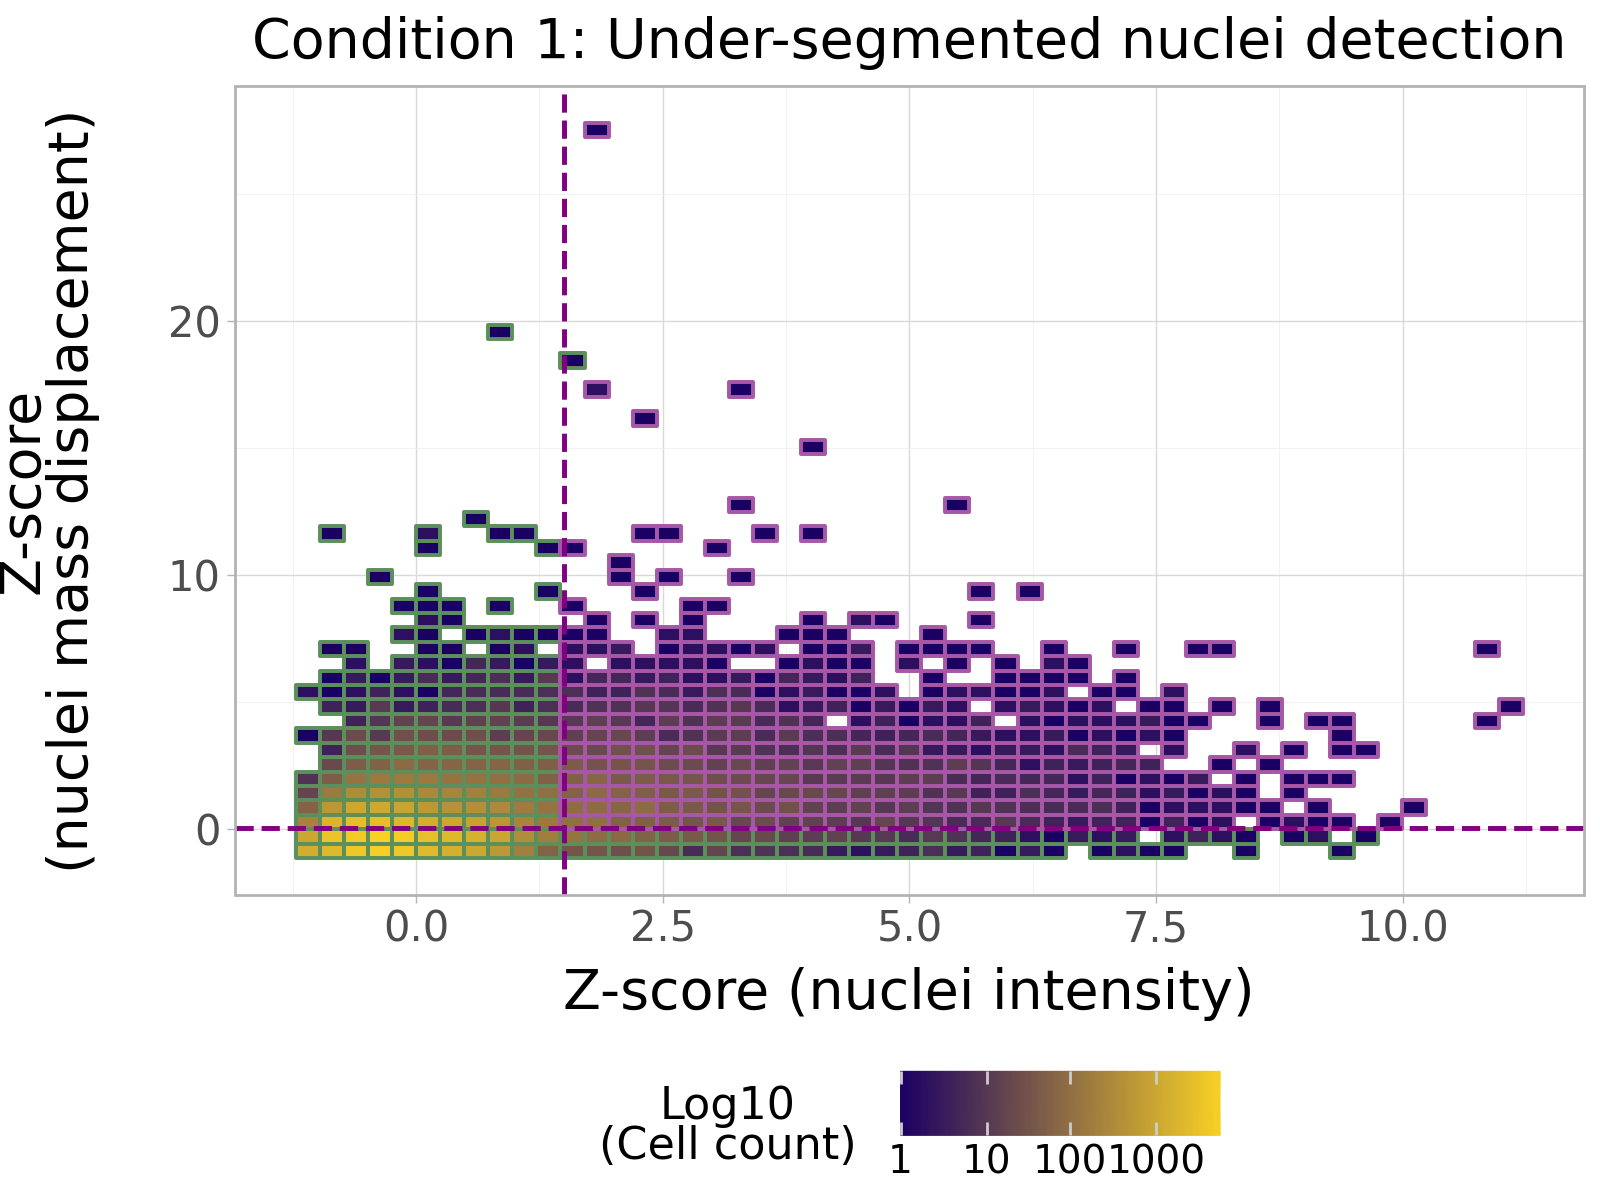

In [6]:
# Rename for easier access
rename_map = {
    "Metadata_cqc_custom_Nuclei_Intensity_IntegratedIntensity_CorrDNA_zscore": "zscore_intensity",  # noqa: E501
    "Metadata_cqc_custom_Nuclei_Intensity_MassDisplacement_CorrDNA_zscore": "zscore_displacement",  # noqa: E501
    "Metadata_cqc_custom_is_outlier": "is_outlier",
}
df = identify_nuclei_clustered_outliers.rename(columns=rename_map)

# Make sure 'is_outlier' is a string or category
df["is_outlier"] = df["is_outlier"].map({True: "Outlier", False: "Not Outlier"})

# Set the figure size
set_option("figure_size", (width, height))

# Plot scatterplot with thresholds for over-segmented nuclei
p = (
    ggplot(df, aes(x="zscore_intensity", y="zscore_displacement", color="is_outlier"))
    + geom_point(alpha=0.3, size=0)
    + geom_bin2d(aes(fill="..count.."), bins=50, alpha=1.0, size=0.8)
    + scale_fill_gradient(
        name="Log10\n(Cell count)", trans="log10", low="#1b0064", high="#f8d125"
    )
    + geom_vline(xintercept=1.5, linetype="--", color="#800080", size=1.0)
    + geom_hline(yintercept=0.05, linetype="--", color="#800080", size=1.0)
    + scale_color_manual(values={"Outlier": "#A658A6", "Not Outlier": "#5C8F5C"})
    + labs(
        x="Z-score (nuclei intensity)",
        y="Z-score\n(nuclei mass displacement)",
        fill="Log10(Cell count)",
    )
    + guides(color=False)  # drop outlier/not outlier legend
    + ggtitle("Condition 1: Under-segmented nuclei detection")
    + theme_light()
    + theme(
        legend_title=element_text(size=16),
        legend_text=element_text(size=14),
        legend_position="bottom",
        legend_direction="horizontal",
        axis_title=element_text(size=20),
        axis_text=element_text(size=15),
        plot_title=element_text(size=20),
        axis_title_y=element_text(
            angle=90,
            vjust=0.5,
            ha="center",
        ),
        plot_margin_left=0.03,
    )
)

# Save the plot
p.save(
    output_dir / "under_segmented_nuclei_plot.png", dpi=600, width=width, height=height
)

# Save version without legend
(p + theme(legend_position="none")).save(
    output_dir / "under_segmented_nuclei_plot_no_legend.png",
    dpi=600,
    width=width,
    height=height,
)

p.show()

In [7]:
# Find large nuclei outliers for the current plate
identify_poor_nuclei_shape_outliers = identify_outliers(
    df=filtered_plate_df,
    # Set at this point where it looks like it starts to detect good quality nuclei
    feature_thresholds={
        "Nuclei_AreaShape_Solidity": -1.6,
    },
    include_threshold_scores=True,
)

pd.DataFrame(identify_poor_nuclei_shape_outliers).head()

,Metadata_cqc_custom_Nuclei_AreaShape_Solidity_zscore,Metadata_cqc_custom_is_outlier
0,0.373790,False
1,0.180780,False
2,0.515060,False
3,-0.179293,False
4,0.642143,False


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/poorly_segmented_nuclei_plot.png
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/poorly_segmented_nuclei_plot_no_legend.png


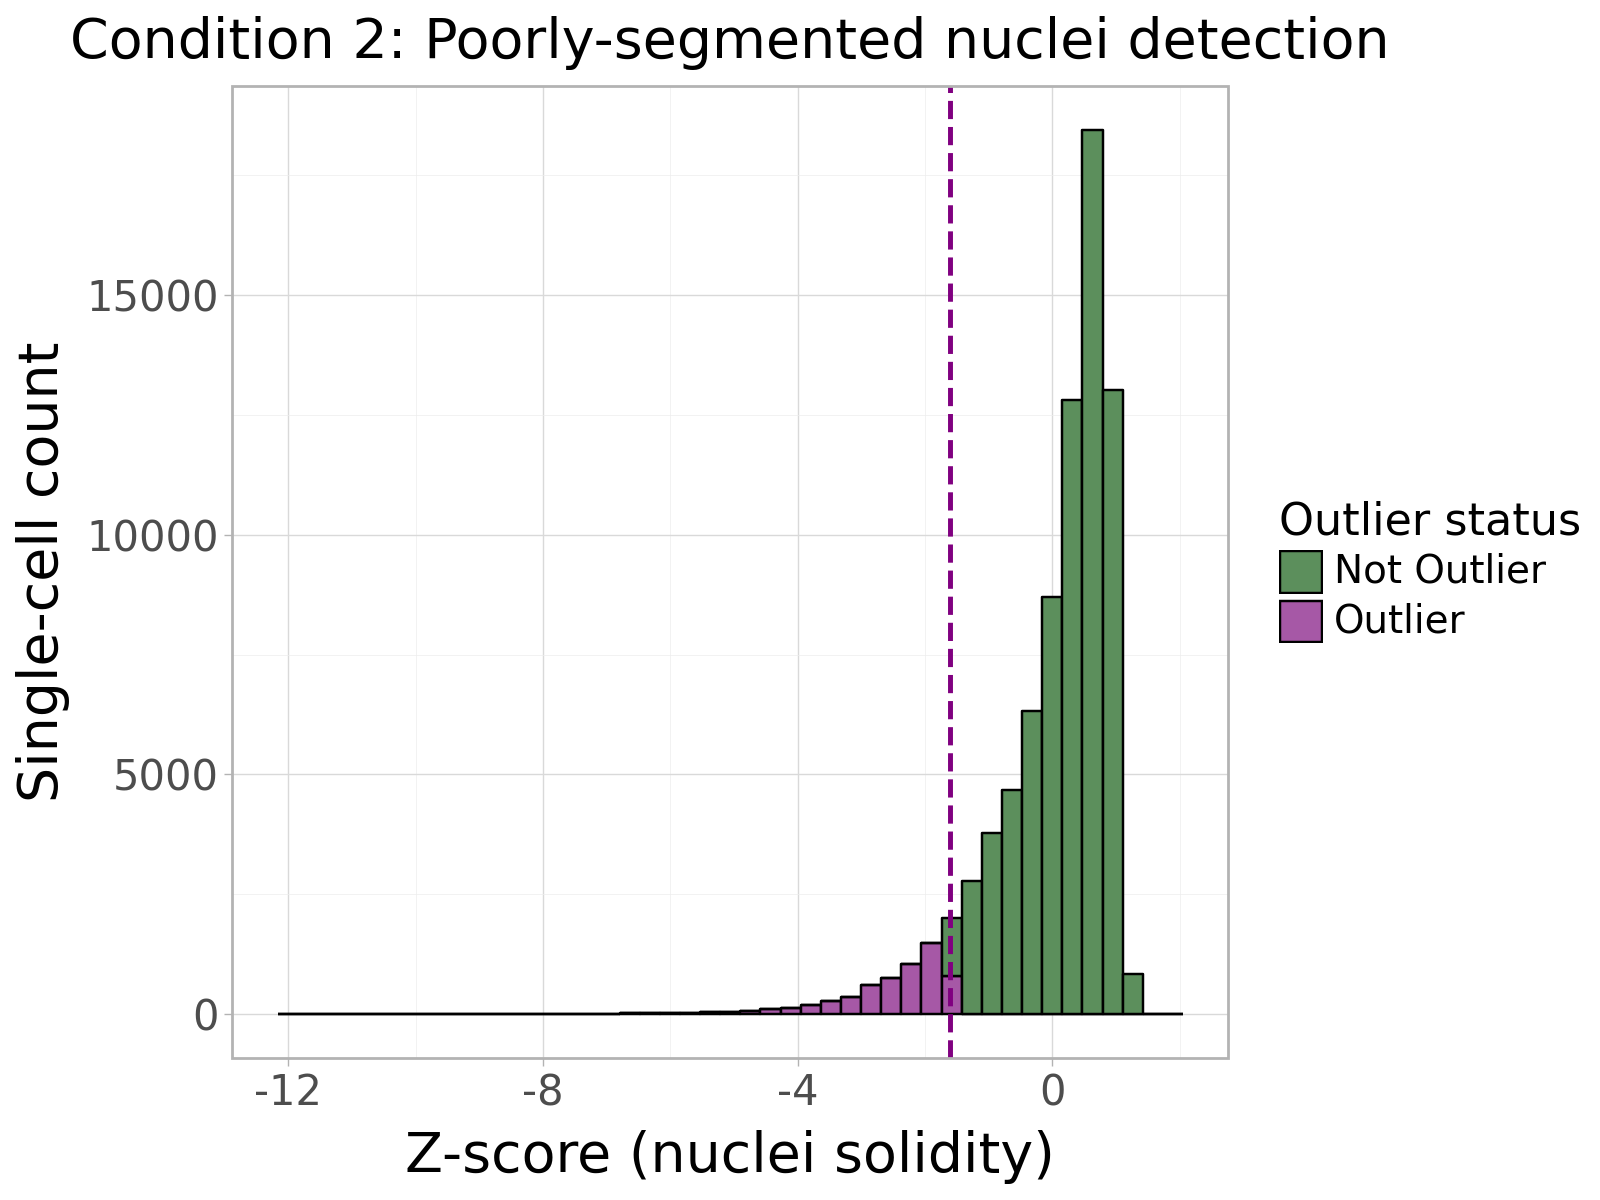

In [8]:
# Rename for easier access
df = identify_poor_nuclei_shape_outliers.rename(
    columns={
        "Metadata_cqc_custom_Nuclei_AreaShape_Solidity_zscore": "zscore_solidity",
        "Metadata_cqc_custom_is_outlier": "is_outlier",
    }
)

# Make sure 'is_outlier' is a string or category (for coloring)
df["is_outlier"] = df["is_outlier"].map({True: "Outlier", False: "Not Outlier"})

# Set the figure size
set_option("figure_size", (width, height))

# Plot histogram for poorly-segmented nuclei
p = (
    ggplot(df, aes(x="zscore_solidity", fill="is_outlier"))
    + geom_histogram(position="stack", bins=45, color="black")
    + scale_fill_manual(values={"Not Outlier": "#5C8F5C", "Outlier": "#A658A6"})
    + geom_vline(
        xintercept=df.loc[df["is_outlier"] == "Outlier", "zscore_solidity"].max(),
        linetype="dashed",
        color="#800080",
        size=1.0,
    )
    + labs(x="Z-score (nuclei solidity)", y="Single-cell count", fill="Outlier status")
    + ggtitle("Condition 2: Poorly-segmented nuclei detection")
    + theme_light()
    + theme(
        legend_title=element_text(size=16),
        legend_text=element_text(size=14),
        legend_position="right",
        axis_title=element_text(size=20),
        axis_text=element_text(size=15),
        plot_title=element_text(
            size=20,
        ),
    )
)

# Save the plot
p.save(
    output_dir / "poorly_segmented_nuclei_plot.png", dpi=600, width=width, height=height
)

# Save version without legend
(p + theme(legend_position="none")).save(
    output_dir / "poorly_segmented_nuclei_plot_no_legend.png",
    dpi=600,
    width=width,
    height=height,
)

p.show()

In [9]:
# Find under-segmented cell outliers for the current plate
under_segmented_cells_outliers = identify_outliers(
    df=filtered_plate_df,
    feature_thresholds={
        # Set low to detect instances of abnormally high int in nuclei for whole cells
        "Cells_Intensity_IntegratedIntensity_CorrDNA": 0.5,
    },
    include_threshold_scores=True,
)

pd.DataFrame(under_segmented_cells_outliers).head()

,Metadata_cqc_custom_Cells_Intensity_IntegratedIntensity_CorrDNA_zscore,Metadata_cqc_custom_is_outlier
0,-0.216969,False
1,-0.375908,False
2,-0.427002,False
3,0.563986,True
4,-0.466745,False


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/under_segmented_cells_plot.png
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/under_segmented_cells_plot_no_legend.png


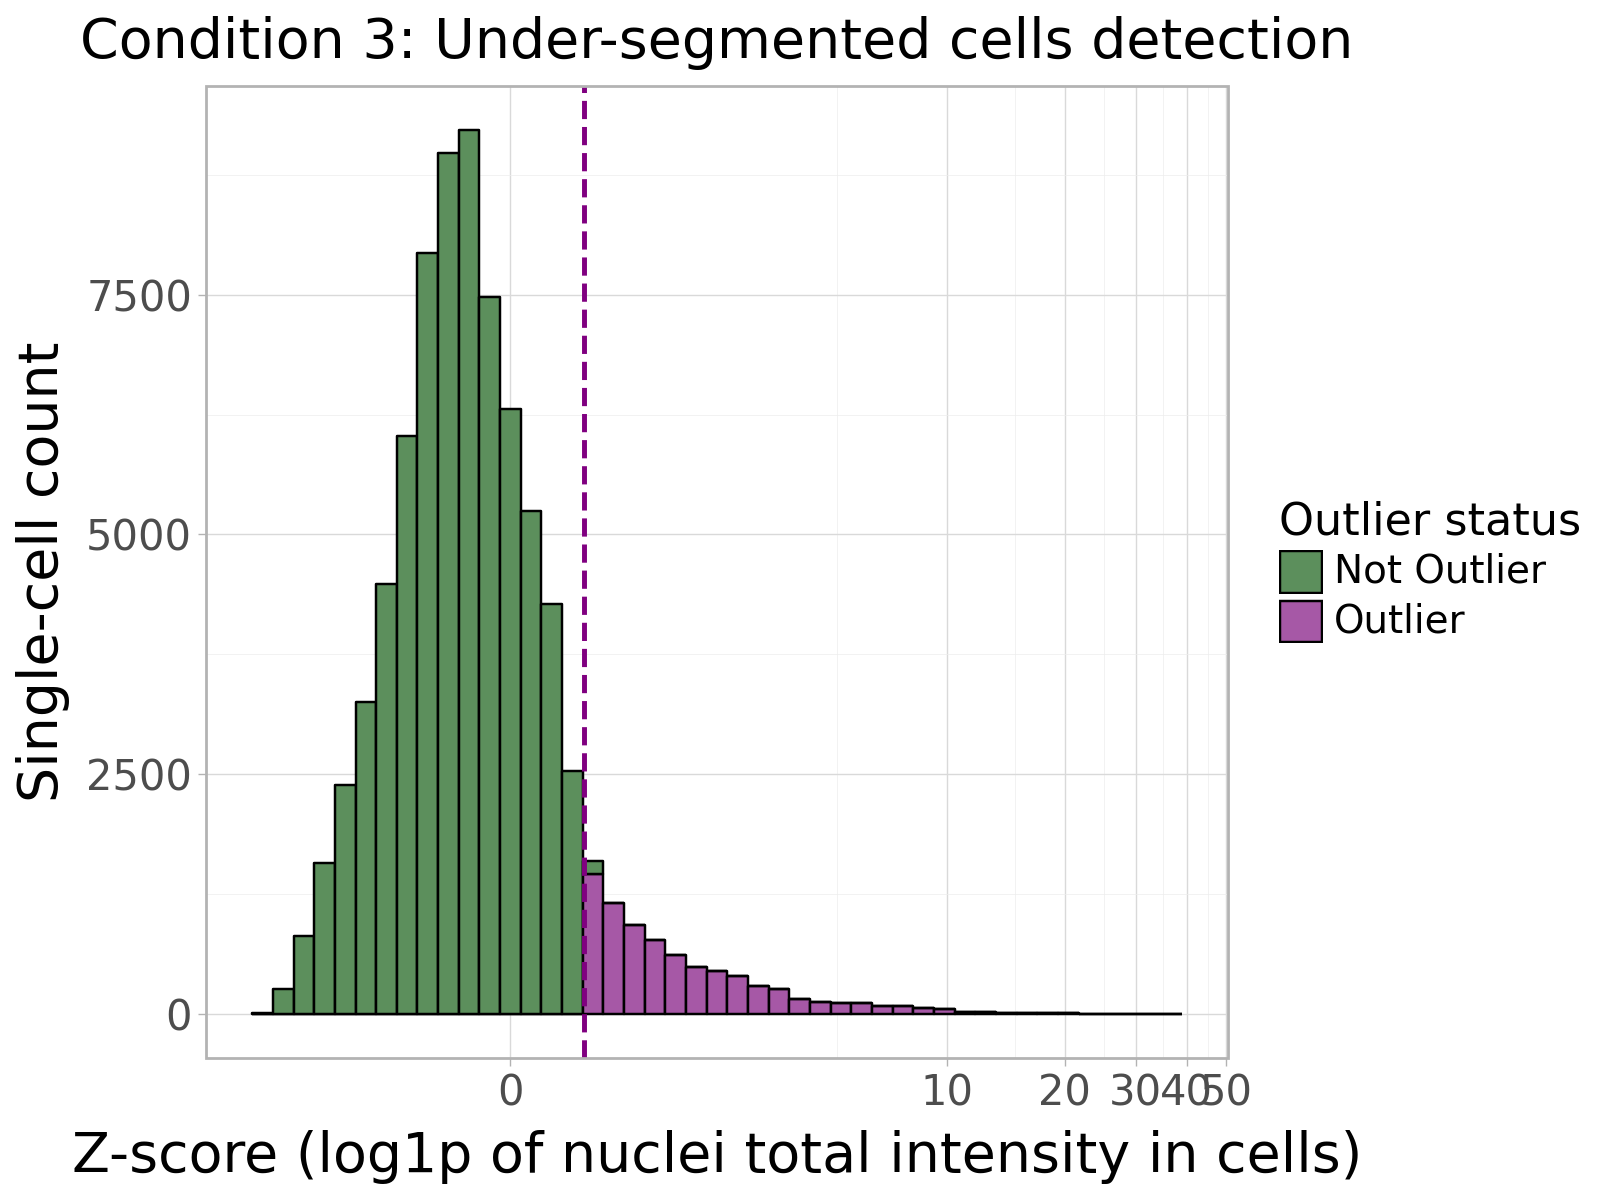

In [10]:
# Rename for easier access
df = under_segmented_cells_outliers.rename(
    columns={
        "Metadata_cqc_custom_Cells_Intensity_IntegratedIntensity_CorrDNA_zscore": "zscore_integrated_intensity",  # noqa: E501
        "Metadata_cqc_custom_is_outlier": "is_outlier",
    }
)

# Make sure 'is_outlier' is a string or category (for coloring)
df["is_outlier"] = df["is_outlier"].map({True: "Outlier", False: "Not Outlier"})

# Set the figure size
set_option("figure_size", (width, height))

p = (
    ggplot(df, aes(x="zscore_integrated_intensity", fill="is_outlier"))
    + geom_histogram(position="stack", bins=45, color="black")
    + scale_fill_manual(values={"Not Outlier": "#5C8F5C", "Outlier": "#A658A6"})
    + geom_vline(
        xintercept=df.loc[
            df["is_outlier"] == "Outlier", "zscore_integrated_intensity"
        ].min(),
        linetype="dashed",
        color="#800080",
        size=1.0,
    )
    + scale_x_continuous(trans="log1p")
    + labs(
        x="Z-score (log1p of nuclei total intensity in cells)",
        y="Single-cell count",
        fill="Outlier status",
    )
    + ggtitle("Condition 3: Under-segmented cells detection")
    + theme_light()
    + theme(
        legend_title=element_text(size=16),
        legend_text=element_text(size=14),
        legend_position="right",
        axis_title=element_text(size=20),
        axis_text=element_text(size=15),
        plot_title=element_text(
            size=20,
        ),
    )
)

# Save the plot
# Save the plot
p.save(
    output_dir / "under_segmented_cells_plot.png", dpi=600, width=width, height=height
)

# Save version without legend
(p + theme(legend_position="none")).save(
    output_dir / "under_segmented_cells_plot_no_legend.png",
    dpi=600,
    width=width,
    height=height,
)

p.show()

## Print out CytoDataFrame to visualize crops

In [11]:
correct_parent = "/media/18tbdrive/ALSF_pilot_data"

for col in filtered_plate_df.columns:
    if "PathName" in col and "Illum" not in col:
        filtered_plate_df[col] = filtered_plate_df[col].apply(
            lambda x: (
                re.sub(r"^.*ALSF_pilot_data/", correct_parent + "/", x)
                if isinstance(x, str)
                else x
            )
        )

# Print example image path after fix
print(filtered_plate_df["Image_PathName_OrigDNA"].dropna().iloc[0])

/media/18tbdrive/ALSF_pilot_data/Round_2_data/Plate 4 All Cell Lines/BR00145816__2024-12-06T16_10_14-Measurement 1/Images


In [12]:
# create an outline and orig mapping dictionary to map original images to outlines
# note: we turn off formatting here to avoid the key-value pairing definition
# from being reformatted by black, which is normally preferred.
# fmt: off
compartment = "Nuclei"

outline_to_orig_mapping = {
    rf"{compartment}Outlines_{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}_{record['Image_Metadata_Site']}.tiff":
    rf"r{int(record['Image_Metadata_Row']):02d}c{int(record['Image_Metadata_Col']):02d}f{int(record['Image_Metadata_Site']):02d}p(\d{{2}})-ch\d+sk\d+fk\d+fl\d+\.tiff"
    for record in filtered_plate_df[
        [
            "Image_Metadata_Plate",
            "Image_Metadata_Well",
            "Image_Metadata_Site",
            "Image_Metadata_Row",
            "Image_Metadata_Col",
        ]
    ].to_dict(orient="records")
}
# fmt: on

next(iter(outline_to_orig_mapping.items()))

('NucleiOutlines_BR00145816_B01_1.tiff',
 'r02c01f01p(\\d{2})-ch\\d+sk\\d+fk\\d+fl\\d+\\.tiff')

Number of outliers: 3630 (4.62%)
Outliers Range:
Nuclei_Intensity_MassDisplacement_CorrDNA Min: 0.5999707298906707
Nuclei_Intensity_MassDisplacement_CorrDNA Max: 14.840765847957671
Nuclei_Intensity_IntegratedIntensity_CorrDNA Min: 389.6632658392191
Nuclei_Intensity_IntegratedIntensity_CorrDNA Max: 1757.922207608819
(3630, 3)


Exclusive reader attempt failed. reader=Reader image='r06c10f06p01-ch5sk1fk1fl1.tiff' error=('file', 'local'):///home/jenna/coSMicQC/docs/manuscripts/cosmicqc_paper_v1/figure_2/r06c10f06p01-ch5sk1fk1fl1.tiff
Exclusive reader attempt failed. reader=Reader image='r10c12f03p01-ch5sk1fk1fl1.tiff' error=('file', 'local'):///home/jenna/coSMicQC/docs/manuscripts/cosmicqc_paper_v1/figure_2/r10c12f03p01-ch5sk1fk1fl1.tiff


,18765,40271
Nuclei_Intensity_MassDisplacement_CorrDNA,0.902517,2.734686
Nuclei_Intensity_IntegratedIntensity_CorrDNA,580.722423,612.600764
Image_FileName_OrigDNA,,

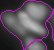
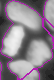

In [13]:
# Find large nuclei outliers for the current plate
nuclei_clustered_outliers = find_outliers(
    df=filtered_plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds={
        "Nuclei_Intensity_MassDisplacement_CorrDNA": 0.05,
        "Nuclei_Intensity_IntegratedIntensity_CorrDNA": 1.5,
    },
)

# MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
nuclei_clustered_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(nuclei_clustered_outliers),
    data_outline_context_dir=f"/media/18tbdrive/1.Github_Repositories/pediatric_cancer_atlas_profiling/2.feature_extraction/sqlite_outputs/Round_2_data/{plate_id}",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": False,
        "outline_color": (180, 30, 180),  # magenta
        "brightness": 20,
    },
)[
    [
        "Nuclei_Intensity_MassDisplacement_CorrDNA",
        "Nuclei_Intensity_IntegratedIntensity_CorrDNA",
        "Image_FileName_OrigDNA",
    ]
]


print(nuclei_clustered_outliers_cdf.shape)
nuclei_clustered_outliers_cdf.sort_values(
    by="Nuclei_Intensity_MassDisplacement_CorrDNA", ascending=True
).sample(n=2, random_state=42).T

Number of outliers: 5982 (7.61%)
Outliers Range:
Nuclei_AreaShape_Solidity Min: 0.6298932384341637
Nuclei_AreaShape_Solidity Max: 0.9082774049217002
(5982, 2)


,Nuclei_AreaShape_Solidity,Image_FileName_OrigDNA
25747,0.908277,
41026,0.908277,
2714,0.908277,
52921,0.908271,

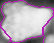
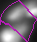

In [14]:
# Find low nuclei solidity outliers for the current plate
solidity_nuclei_outliers = find_outliers(
    df=filtered_plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds={
        # Set at this point where it looks like it starts to detect good quality nuclei
        "Nuclei_AreaShape_Solidity": -1.6,
    },
)

# Convert to CytoDataFrame for outline viewing
solidity_nuclei_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(solidity_nuclei_outliers),
    data_outline_context_dir=f"/media/18tbdrive/1.Github_Repositories/pediatric_cancer_atlas_profiling/2.feature_extraction/sqlite_outputs/Round_2_data/{plate_id}",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": False,
        "brightness": 20,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Nuclei_AreaShape_Solidity",
        "Image_FileName_OrigDNA",
    ]
]


print(solidity_nuclei_outliers_cdf.shape)
solidity_nuclei_outliers_cdf.sort_values(
    by="Nuclei_AreaShape_Solidity", ascending=False
).head(4)

In [15]:
# change compartment to cells
compartment = "Cells"

# metadata columns to include in output data frame
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    f"Metadata_{compartment}_Location_Center_X",
    f"Metadata_{compartment}_Location_Center_Y",
    "Image_FileName_OrigDNA",
    "Image_FileName_OrigAGP",
    "Image_PathName_OrigDNA",
    "Image_PathName_OrigAGP",
    f"{compartment}_AreaShape_BoundingBoxMaximum_X",
    f"{compartment}_AreaShape_BoundingBoxMaximum_Y",
    f"{compartment}_AreaShape_BoundingBoxMinimum_X",
    f"{compartment}_AreaShape_BoundingBoxMinimum_Y",
    "Image_Metadata_Row",
    "Image_Metadata_Col",
    "Metadata_Nuclei_Number_Object_Number",
]

# Define the QC features
qc_features = [
    "Nuclei_Intensity_IntegratedIntensity_CorrDNA",
    "Nuclei_AreaShape_Solidity",
    "Nuclei_Intensity_MassDisplacement_CorrDNA",
    "Cells_Intensity_IntegratedIntensity_CorrDNA",
]

# Filter plate_df to only include metadata columns and QC features
filtered_plate_df = example_df[metadata_columns + qc_features]

# create an outline and orig mapping dictionary to map original images to outlines
# note: we turn off formatting here to avoid the key-value pairing definition
# from being reformatted by black, which is normally preferred.
# fmt: off
outline_to_orig_mapping = {
    rf"{compartment}Outlines_{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}_{record['Image_Metadata_Site']}.tiff":
    rf"r{int(record['Image_Metadata_Row']):02d}c{int(record['Image_Metadata_Col']):02d}f{int(record['Image_Metadata_Site']):02d}p(\d{{2}})-ch\d+sk\d+fk\d+fl\d+\.tiff"
    for record in filtered_plate_df[
        [
            "Image_Metadata_Plate",
            "Image_Metadata_Well",
            "Image_Metadata_Site",
            "Image_Metadata_Row",
            "Image_Metadata_Col",
        ]
    ].to_dict(orient="records")
}
# fmt: on

next(iter(outline_to_orig_mapping.items()))

('CellsOutlines_BR00145816_B01_1.tiff',
 'r02c01f01p(\\d{2})-ch\\d+sk\\d+fk\\d+fl\\d+\\.tiff')

In [16]:
correct_parent = "/media/18tbdrive/ALSF_pilot_data"

for col in filtered_plate_df.columns:
    if "PathName" in col and "Illum" not in col:
        filtered_plate_df[col] = filtered_plate_df[col].apply(
            lambda x: (
                re.sub(r"^.*ALSF_pilot_data/", correct_parent + "/", x)
                if isinstance(x, str)
                else x
            )
        )

# Print example image path after fix
print(filtered_plate_df["Image_PathName_OrigDNA"].dropna().iloc[0])

/media/18tbdrive/ALSF_pilot_data/Round_2_data/Plate 4 All Cell Lines/BR00145816__2024-12-06T16_10_14-Measurement 1/Images


Number of outliers: 7714 (9.81%)
Outliers Range:
Cells_Intensity_IntegratedIntensity_CorrDNA Min: 360.4617034448311
Cells_Intensity_IntegratedIntensity_CorrDNA Max: 11016.348135018721
(7714, 2)


,Cells_Intensity_IntegratedIntensity_CorrDNA,Image_FileName_OrigDNA
37168,709.754514,
40740,1308.300228,

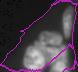
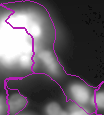

In [17]:
# Find cell outliers for the current plate
cell_outliers = find_outliers(
    df=filtered_plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds={
        # Set low to attempt to detect all instances of abnormally high int in nuclei for whole cells  # noqa: E501
        "Cells_Intensity_IntegratedIntensity_CorrDNA": 0.5,
    },
)

# Convert to CytoDataFrame for outline viewing
cell_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(cell_outliers),
    data_outline_context_dir=f"/media/18tbdrive/1.Github_Repositories/pediatric_cancer_atlas_profiling/2.feature_extraction/sqlite_outputs/Round_2_data/{plate_id}",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": False,
        "brightness": 20,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Cells_Intensity_IntegratedIntensity_CorrDNA",
        "Image_FileName_OrigDNA",
    ]
]


print(cell_outliers_cdf.shape)
cell_outliers_cdf.sort_values(
    by="Cells_Intensity_IntegratedIntensity_CorrDNA", ascending=True
).sample(n=2, random_state=42)

In [18]:
# platemap file path
platemap_file = Path(
    "/media/18tbdrive/1.Github_Repositories/pediatric_cancer_atlas_profiling/0.download_data/metadata/platemaps/Assay_Plate4_platemap.csv"
)
platemap_df = pd.read_csv(platemap_file)

# Rename Image_Metadata_Site to Metadata_Site prior to annotation
filtered_plate_df = filtered_plate_df.rename(columns={"Image_Metadata_Site": "Metadata_Site"})

# Annotate the filtered_plate_df with metadata from platemap
annotated_plate_df = annotate(
    profiles=filtered_plate_df,
    platemap=platemap_df,
    join_on=["Metadata_well", "Image_Metadata_Well"],
)
print(annotated_plate_df.shape)
annotated_plate_df.head()

(75395, 25)


,Metadata_cell_line,Metadata_row,Metadata_column,Metadata_seeding_density,Metadata_condition,Metadata_Plate,Metadata_Well,Metadata_Site,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,Cells_AreaShape_BoundingBoxMinimum_X,Cells_AreaShape_BoundingBoxMinimum_Y,Image_Metadata_Row,Image_Metadata_Col,Nuclei_Intensity_IntegratedIntensity_CorrDNA,Nuclei_AreaShape_Solidity,Nuclei_Intensity_MassDisplacement_CorrDNA,Cells_Intensity_IntegratedIntensity_CorrDNA
0,CHLA-10,B,3,1000,synthemax_PFA,BR00145816,B03,2,245.499080,174.545371,...,276.0,213.0,215.0,136.0,2,3,765.939727,0.981288,1.468688,788.089049
1,CHLA-10,B,3,1000,synthemax_PFA,BR00145816,B03,3,969.283133,10.843373,...,980.0,19.0,962.0,2.0,2,3,11.852596,0.937063,0.210698,12.318306
2,CHLA-10,B,3,1000,synthemax_PFA,BR00145816,B03,4,789.956012,264.771261,...,814.0,295.0,764.0,241.0,2,3,327.168328,0.963107,1.584961,342.412609
3,CHLA-10,B,3,1000,synthemax_PFA,BR00145816,B03,5,330.538505,65.403737,...,386.0,97.0,290.0,30.0,2,3,503.389291,0.976558,0.462842,540.055422
4,CHLA-10,B,3,1000,synthemax_PFA,BR00145816,B03,7,940.935980,114.332907,...,963.0,131.0,922.0,98.0,2,3,32.914259,0.951743,0.535042,43.821652


In [19]:
all_outlier_keys = set(
    pd.concat([nuclei_clustered_outliers, solidity_nuclei_outliers, cell_outliers])[
        [
            "Image_Metadata_Plate",
            "Image_Metadata_Well",
            "Image_Metadata_Site",
            "Metadata_Nuclei_Number_Object_Number",
        ]
    ].apply(tuple, axis=1)
)

# Rename well and plate to just Metadata_ prefix
all_outlier_keys = {
    (plate, well, site, int(obj_num))
    for (plate, well, site, obj_num) in all_outlier_keys
}


# Create failed_qc column, default to False
annotated_plate_df["failed_qc"] = False
# Set to True where the cell matches the outlier dataframe
annotated_plate_df.loc[
    annotated_plate_df[
        [
            "Metadata_Plate",
            "Metadata_Well",
            "Metadata_Site",
            "Metadata_Nuclei_Number_Object_Number",
        ]
    ]
    .apply(tuple, axis=1)
    .isin(all_outlier_keys),
    "failed_qc",
] = True

# Check result
annotated_plate_df["failed_qc"].value_counts()

failed_qc
False    63297
True     12098
Name: count, dtype: int64

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 16 x 5 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/failed_qc_summary.png


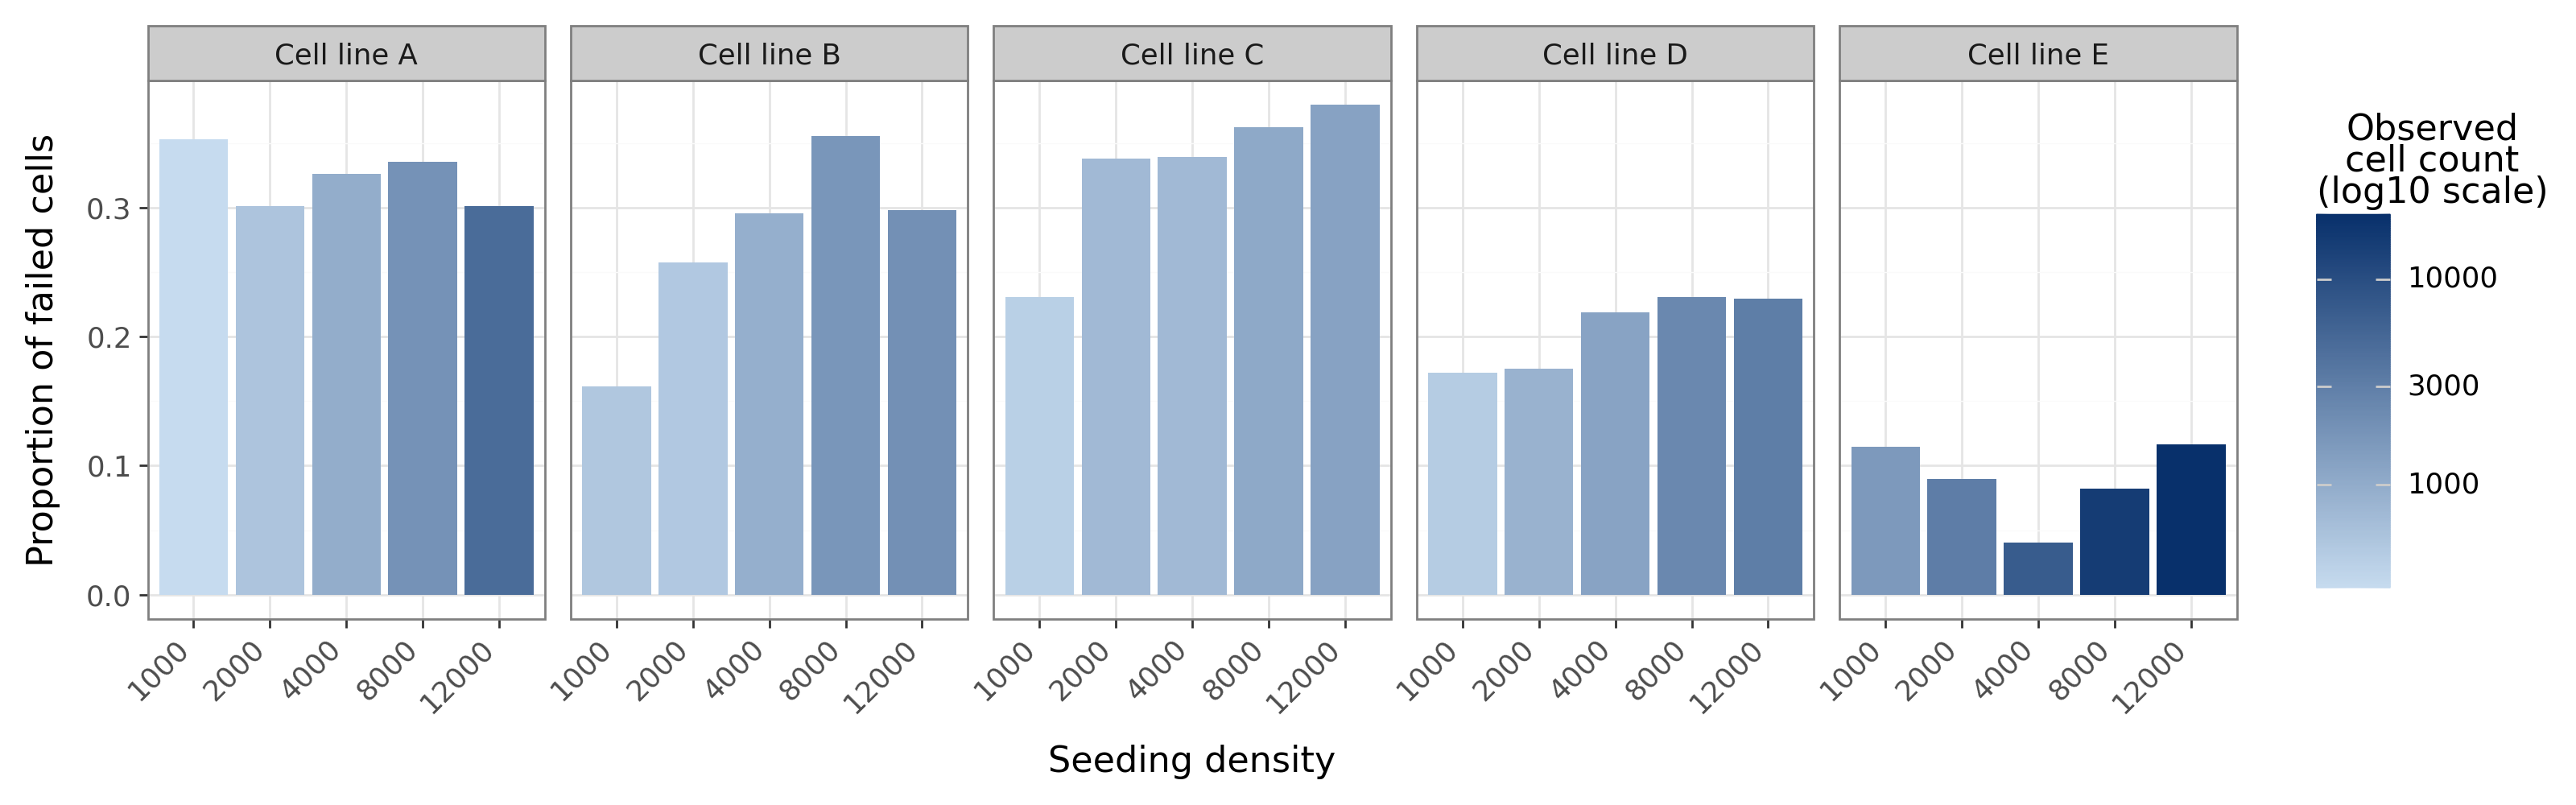

In [20]:
# Group by cell line & seeding density, & calculate total nuclei segmented and failed QC
failure_stats = (
    annotated_plate_df.groupby(
        [
            "Metadata_cell_line",
            "Metadata_seeding_density",
            "Metadata_condition",
            "Metadata_Plate",
        ]
    )
    .agg(
        total_nuclei_segmented=("failed_qc", "count"),
        total_failed_qc=("failed_qc", "sum"),
        percentage_failing_cells=("failed_qc", "mean"),
    )
    .reset_index()
)

# Blind the cell line names
cell_line_map = {
    "CHLA-10": "Cell line A",
    "CHLA-113": "Cell line B",
    "CHLA-218": "Cell line C",
    "CHLA-25": "Cell line D",
    "U2-OS": "Cell line E",
}
failure_stats["Metadata_cell_line"] = failure_stats["Metadata_cell_line"].map(
    cell_line_map
)

# Set the figure size
width = 16
height = 5
set_option("figure_size", (width, height))

# Plot using plotnine
p = (
    ggplot(
        failure_stats,
        aes(
            x="factor(Metadata_seeding_density)",
            y="percentage_failing_cells",
            fill="total_nuclei_segmented",
        ),
    )
    + geom_bar(stat="identity")
    + facet_wrap("~Metadata_cell_line", nrow=1, scales="free_x")
    + labs(
        x="Seeding density",
        y="Proportion of failed cells",
        fill="Observed\ncell count\n(log10 scale)",
    )
    + scale_fill_gradient(
        low="#C6DBEF",
        high="#08306B",
        trans="log10",
    )
    + theme_bw(base_size=16)
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)

# Save the plot
p.save(f"{output_dir}/failed_qc_summary.png", dpi=600, width=width, height=height)
p.show()

## Export sub-sampled dataset of equal passing and failing QC cells for manual annotation

To compare failed and passed QC cells, we use a balanced stratified random sample. The sample includes the same number of failed and passed cells, and within each QC group the cells are split evenly across cell lines represented in both groups.

In [21]:
# Define parameters for stratified sampling
n_cells_per_qc_group = 200
stratify_column = "Metadata_cell_line"
qc_column = "failed_qc"
random_seed = 0

# Check that both QC groups are present and get the unique cell lines in each group
strata_by_qc = annotated_plate_df.groupby(qc_column)[stratify_column].unique()
expected_qc_groups = {False, True}

# Validate that both expected QC groups are present
if set(strata_by_qc.index) != expected_qc_groups:
    raise ValueError(
        f"Expected both passed and failed QC groups, found {set(strata_by_qc.index)}."
    )

# Get the shared cell lines across both QC groups to ensure we can stratify properly
shared_cell_lines = sorted(set.intersection(*[set(x) for x in strata_by_qc]))

# Ensure there are shared cell lines to stratify on
if not shared_cell_lines:
    raise ValueError(
        "No cell lines are represented in both passed and failed QC groups."
    )

# Calculate the number of samples to draw from each stratum
base_n, extra_n = divmod(n_cells_per_qc_group, len(shared_cell_lines))
# Instantiate list to hold sampled dataframes
sampled_dfs = []

# Perform stratified sampling within each QC group and cell line
for qc_idx, qc_value in enumerate(sorted(expected_qc_groups)):
    for cell_line_idx, cell_line in enumerate(shared_cell_lines):
        # Calculate the number of samples to draw from this stratum,
        # adding one more sample to the first 'extra_n' strata to account for any remainder  # noqa: E501
        n_to_sample = base_n + int(cell_line_idx < extra_n)
        # Subset the dataframe for the current stratum
        stratum_df = annotated_plate_df.loc[
            (annotated_plate_df[qc_column] == qc_value)
            & (annotated_plate_df[stratify_column] == cell_line)
        ]

        # Sample from the stratum and append to the list
        sampled_dfs.append(
            stratum_df.sample(
                n=n_to_sample,
                replace=False,  # Do not replace to avoid duplicates in the sample
                random_state=random_seed + qc_idx * 1000 + cell_line_idx,
            )
        )

# Combine the sampled dataframes into one
qc_sample_df = pd.concat(sampled_dfs, ignore_index=True)

# Save the stratified sample for use manual annotation of QC status
subset_output_dir = Path("./data")
subset_output_dir.mkdir(parents=True, exist_ok=True)
# Set output path
output_path = subset_output_dir / "stratified_qc_sample.parquet"

# Will not overwrite if file already exists
if output_path.exists():
    warnings.warn(
        f"{output_path} already exists. Skipping save to avoid overwrite.", UserWarning
    )
else:
    qc_sample_df.to_parquet(output_path, index=False)
    print("Stratified sample saved to:", output_path)

    # Verify the stratified sampling worked as expected
    print(
        qc_sample_df.groupby([stratify_column, qc_column]).size().unstack(fill_value=0)
    )

/tmp/ipykernel_3488746/327294676.py:63: UserWarning: data/stratified_qc_sample.parquet already exists. Skipping save to avoid overwrite.
